# Teknofest Gelişmiş Çözüm Aşaması — Talep Deseni Analizi ve Yöntem Kararları

Bu defter, talep tahmini ve taşıma planı optimizasyonu tasarımını yönlendiren
keşifçi veri analizini (EDA) belgeler: haftalık/aylık talep deseni, tahmin
yöntemi backtest'i, ve hat bazlı hacim analizinin neden milk-run
(çok-duraklı uğrama) mimarisine yönlendirdiği.

Üretim kodu `src/` altındadır; bu defter sadece **karar gerekçelerini**
gösterir, pipeline `main.py` ile çalıştırılır.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt

from src import data_loader as dl, demand_forecast as fc, config

pd.set_option("display.width", 120)
talep = dl.load_gecmis_talep()
print(f"{len(talep):,} satır, {talep['tarih'].min().date()} - {talep['tarih'].max().date()}")
print(f"Benzersiz hat sayısı: {talep[['cikis','varis']].drop_duplicates().shape[0]}")

66,024 satır, 2026-01-01 - 2026-06-28
Benzersiz hat sayısı: 289


## 1. Haftalık sezonluk desen

Talep, haftanın gününe göre çok belirgin bir dalgalanma gösteriyor.

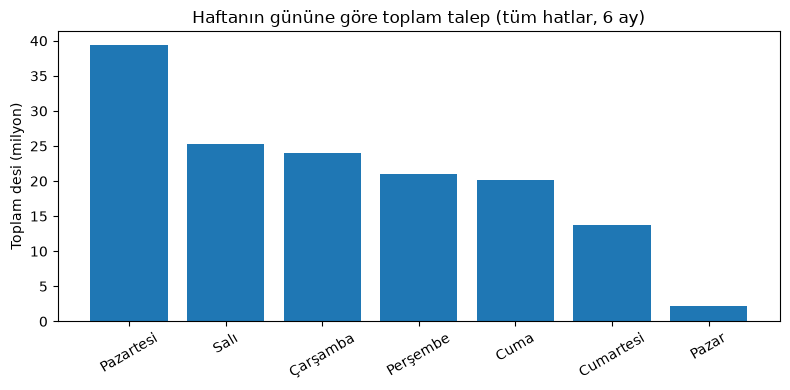

dow
0    27.0
1    17.3
2    16.5
3    14.4
4    13.8
5     9.4
6     1.5
Name: % pay, dtype: float64


In [2]:
talep['dow'] = talep['tarih'].dt.dayofweek
gun_adlari = ['Pazartesi','Salı','Çarşamba','Perşembe','Cuma','Cumartesi','Pazar']
gunluk = talep.groupby('dow')['toplam_desi'].sum()

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(gun_adlari, gunluk.values / 1e6)
ax.set_ylabel('Toplam desi (milyon)')
ax.set_title('Haftanın gününe göre toplam talep (tüm hatlar, 6 ay)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print((gunluk / gunluk.sum() * 100).round(1).rename('% pay'))

**Gözlem:** Pazartesi en yoğun gün (toplamın %23'ü), Pazar neredeyse talepsiz
(%2). Bu desen, talep tahmini yönteminin haftanın gününe duyarlı olması
gerektiğini gösteriyor.

## 2. Aylık trend

Ocak ayı bir başlangıç dönemi gibi görünüyor; Şubat'tan itibaren
seviye stabilize oluyor.

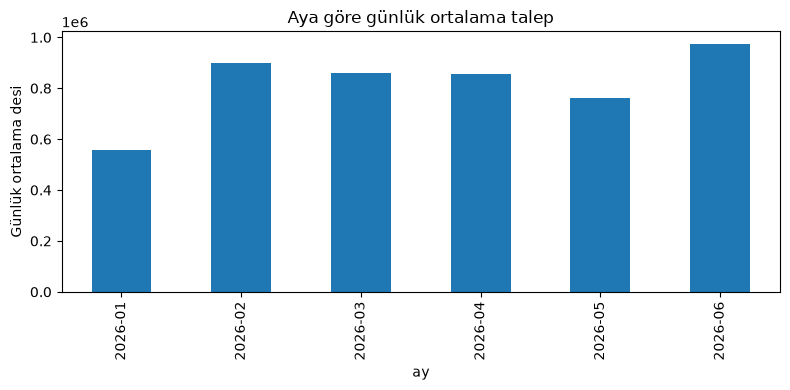

In [3]:
talep['ay'] = talep['tarih'].dt.to_period('M')
aylik = talep.groupby('ay')['toplam_desi'].sum() / talep.groupby('ay')['tarih'].nunique()

fig, ax = plt.subplots(figsize=(8,4))
aylik.plot(kind='bar', ax=ax)
ax.set_ylabel('Günlük ortalama desi')
ax.set_title('Aya göre günlük ortalama talep')
plt.tight_layout()
plt.show()

**Sonuç:** Ocak verisi güvenilmez (ramp-up), tahmin yönteminde son
haftalara daha fazla ağırlık verilmesi gerekiyor — bu, aşağıdaki ağırlıklı
ortalama yaklaşımını motive ediyor.

## 2b. Veri kalitesi: eğitim dışı bırakılan günler

Takvimde üç anormal bölge var ve zero-fill yaklaşımı bunları sahte gözleme
çevirir (kayıt yok = 0 desi sayıldığı için):

1. **28 Haziran** — kısmi gün: 47 satır (normal gün ~370), verinin kesildiği yer.
2. **26 Mayıs – 1 Haziran** — Kurban Bayramı: arife yarım günü, bayramda
   talep ~sıfır (27 Mayıs: 104 desi), 1 Haziran'da 2.64M desilik telafi
   patlaması (normal günün ~3 katı).

Tahmin haftasında (29 Haz – 5 Tem) tatil yok; bu günler haftalık ortalamaya
girdiğinde sistematik yanlılık yaratıyor: Pazartesi ~%6 şişkin (1 Haziran
etkisi), Çarşamba–Cumartesi ~%9 düşük (bayram sıfırları). Bu günler
`demand_forecast.HARIC_GUNLER` ile takvim ızgarasından tamamen çıkarılır
(sadece satır silmek yetmez — zero-fill onları 0'a çevirirdi).

In [4]:
gunluk_ozet = talep.groupby('tarih').agg(satir=('toplam_desi', 'size'), desi=('toplam_desi', 'sum'))
print("Kurban penceresi (25 Mayıs - 3 Haziran):")
print(gunluk_ozet.loc['2026-05-25':'2026-06-03'].to_string())
print(f"\nSon 3 gün (28 Haziran kısmi):")
print(gunluk_ozet.tail(3).to_string())
print(f"\nNormal gün ortalaması: {gunluk_ozet['satir'].median():.0f} satır, {gunluk_ozet['desi'].median():,.0f} desi")

Kurban penceresi (25 Mayıs - 3 Haziran):
            satir     desi
tarih                     
2026-05-25    401   919753
2026-05-26    298   193306
2026-05-27      2      104
2026-05-28      2      105
2026-05-29     14     3077
2026-05-30     42    42971
2026-05-31     10     2010
2026-06-01    444  2637199
2026-06-02    480  1392559
2026-06-03    448  1088155

Son 3 gün (28 Haziran kısmi):
            satir    desi
tarih                    
2026-06-26    404  805414
2026-06-27    370  524096
2026-06-28     47   81409

Normal gün ortalaması: 436 satır, 893,803 desi


## 3. Talep tahmini yöntemi: ağırlıklı haftalık ortalama + harman + çok pencereli backtest

Yöntem: her (hat, saat) için haftanın gününe göre üstel azalan ağırlıklı
ortalama (`src/demand_forecast.py`), bölüm 2b'deki günler eğitim dışı.

Tek pencere doğrulama yanıltıcı olabildiğinden hem hariç tutulan gün seti
hem yarı ömür (halflife) hem harman ağırlığı **3 ayrı temiz haftada** test
edilir; recency ağırlığının referansı her pencerede eğitim sonuna çekilir
(üretim koşullarının birebir taklidi). Aşağıdaki hesap bu backtesti doğrudan
üretir.

In [5]:
import numpy as np

# 3 temiz dogrulama penceresi (Pzt-Paz)
PENCERELER = [(pd.Timestamp("2026-06-21"), pd.Timestamp("2026-06-27")),
              (pd.Timestamp("2026-06-14"), pd.Timestamp("2026-06-20")),
              (pd.Timestamp("2026-06-07"), pd.Timestamp("2026-06-13"))]
KEY = ["cikis", "varis", "talep_tamamlanma_saati", "tarih"]
daily = fc._full_calendar_daily(talep)


def wmape(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return 100 * np.abs(y - p).sum() / max(y.sum(), 1e-9)


def pencere_wmape(bas, son, haric, w=1.0):
    """Pencere WMAPE'si. w<1 ise agirlikli tahmin lag-toplulugu ile harmanlanir.
    Egitim = pencereden onceki gunler; recency referansi pencere baslangicidir."""
    egit = daily[(daily["tarih"] < bas) & (~daily["tarih"].isin(haric))]
    hedef = list(pd.date_range(bas, son))
    agir = fc._weighted_weekday_forecast(egit, hedef, 3.0, referans=bas - pd.Timedelta(days=1))
    m = (daily[(daily["tarih"] >= bas) & (daily["tarih"] <= son)]
         .merge(agir.rename(columns={"tahmin": "a"}), on=KEY, how="left"))
    m["a"] = m["a"].fillna(0.0)
    if w < 1.0:
        lag = fc._lag_ensemble_forecast(talep[talep["tarih"] < bas], hedef)
        m = m.merge(lag.rename(columns={"tahmin": "l"}), on=KEY, how="left")
        m["l"] = m["l"].fillna(m["a"])
        pred = (w * m["a"] + (1 - w) * m["l"]).clip(lower=0)
    else:
        pred = m["a"].clip(lower=0)
    return wmape(m["toplam_desi"], pred)


# 1) Haric-gun temizliginin etkisi (halflife=3)
setler = {"haric yok": [], "28 Haziran": list(fc.KISMI_GUNLER),
          "+ Kurban/arife (uretim)": list(fc.HARIC_GUNLER)}
t1 = pd.DataFrame([{"haric-gun seti": ad,
                    **{f"P{i+1}": round(pencere_wmape(b, s, h), 2) for i, (b, s) in enumerate(PENCERELER)},
                    "ORT": round(np.mean([pencere_wmape(b, s, h) for b, s in PENCERELER]), 2)}
                   for ad, h in setler.items()])
display(t1)

# 2) Harman agirligi taramasi (uretim haric-gun setiyle)
t2 = pd.DataFrame([{"w (agirlikli)": w,
                    "ORT WMAPE": round(np.mean([pencere_wmape(b, s, list(fc.HARIC_GUNLER), w)
                                                for b, s in PENCERELER]), 2)}
                   for w in [1.00, 0.90, 0.85, 0.80, 0.70]])
t2

,haric-gun seti,P1,P2,P3,ORT
0,haric yok,21.50,26.74,21.09,23.11
1,28 Haziran,21.50,26.74,21.09,23.11
2,+ Kurban/arife (uretim),23.81,21.33,18.96,21.37


,w (agirlikli),ORT WMAPE
0,1.00,21.37
1,0.90,21.16
2,0.85,21.09
3,0.80,21.04
4,0.70,21.03


Yukarıdaki iki tablonun okunuşu:

- **Hariç-gün temizliği**: 3 pencere ortalaması %23.11'den %21.37'ye düşer.
  (Halflife'ta 3 ile 4 hafta pratikte eşit — %21.37 / %21.35 — mevcut 3 hafta
  korunur.)
- **Harman ağırlığı**: ağırlıklı ortalama, ikinci bir bağımsız tahminciyle —
  sağlam mevsimsel lag topluluğu (son 4 haftanın aynı-günü,
  `0.5·min-atılmış-ortalama + 0.5·medyan`) — harmanlanır. İki yöntem farklı
  hatalar yaptığından (biri haftalık yapıyı, diğeri güncel seviyeyi daha iyi
  yakalar) harman ikisinden de düşük WMAPE verir. Ağırlık 0.85, WMAPE'yi
  21.37 → 21.09 düşürürken optimizasyonda SLA cezasını sıfırda tutan en yüksek
  değerdir (0.80'den itibaren İstanbul elleçleme doygunluğu bir yükü
  geciktirip küçük bir ceza doğuruyor).

**GBM ile karşılaştırma (denendi, kaybetti):** LightGBM (tweedie 1.25,
lag≥7 + haftalık takvim özellikleri) aynı 3 pencerede iki varyantla test edildi:

| Yöntem | P1 | P2 | P3 | ORT |
|---|---:|---:|---:|---:|
| Harman (üretim) | 23.20 | 21.41 | 18.65 | 21.09 |
| LightGBM (anomali günler NaN) | 25.13 | 26.16 | 40.55 | 30.61 |
| LightGBM (anomali sadece hedefte hariç) | 27.17 | 24.77 | 27.50 | 26.48 |

GBM'in kaybetme nedeni yapısal: seri başına ~25 haftalık kısa geçmiş ve
bayram deliğinin yakın lag'leri bozması, buna karşın hedefin güçlü ve
istikrarlı haftalık sezonluğu — elle kurulmuş tahminciler bu rejimde düşük
varyanslı ve zor yenilir.

## 4. Hat bazlı hacim analizi — neden milk-run gerekli?

Talep tahmini üretildikten sonra, her hattın **haftalık toplam** tahmini
talebine bakıldığında çarpıcı bir dağılım ortaya çıkıyor.

In [6]:
forecast = fc.forecast_all(talep)
haftalik = forecast.groupby(['cikis','varis'])['tahmin_desi'].sum().sort_values()

print(f"Toplam hat sayısı: {len(haftalik)}")
print(haftalik.describe())
print()
for esik in [5600, 12000, 22400]:
    print(f"Haftalık toplam < {esik:>6} (bir aracı bile dolduramaz): "
          f"{(haftalik<esik).sum()} / {len(haftalik)} hat")

Toplam hat sayısı: 289
count       289.000000
mean      22466.650519
std       36516.370783
min          93.000000
25%        2580.000000
50%        8101.000000
75%       24381.000000
max      209503.000000
Name: tahmin_desi, dtype: float64

Haftalık toplam <   5600 (bir aracı bile dolduramaz): 122 / 289 hat
Haftalık toplam <  12000 (bir aracı bile dolduramaz): 169 / 289 hat
Haftalık toplam <  22400 (bir aracı bile dolduramaz): 207 / 289 hat


**Kritik bulgu:** 289 hattan 122'si (%42), tüm haftanın talebi biriktirilse
bile en küçük aracı (Kamyonet, 5600 desi) dahi dolduramıyor. SLA süresi
1-2 gün olduğundan gerçek biriktirme penceresi haftadan çok daha kısa. Bu,
coğrafi konsolidasyonun (aynı çıkıştan farklı hedeflere giden ince yüklerin
tek bir çok-duraklı araçta birleştirilmesi) zorunlu olduğunu gösteriyor —
salt zamanda bekletme yetmiyor.

Hub-and-spoke (ara merkezde indirip-yeniden-yükleme) mimarisi çift elleçleme
gerektirdiğinden kıt elleçleme kapasitesini tıkar ve SLA cezasını yükseltir.
Bunun yerine **milk-run** (aynı aracın `çıkış → durak1 → durak2 → ...`
şeklinde sırayla uğraması, sadece o durakta inen yükün elleçlenmesi)
kullanılır — hem organizatörce yazılı onaylı (Q&A soru 11: spot araçlar için
uğrama serbest) hem de çift elleçleme sorununu kökten çözer.

## 5. Sonuç: yöntem karşılaştırması

Üç farklı optimizasyon mimarisi denendi, tam veri setinde (7 gün, 4046 talep)
ölçüldü:

In [7]:
ozet = pd.DataFrame({
    'Aşama': ['v1: Direkt sevkiyat (uğrama yok)',
              'v2: Hub-and-spoke konsolidasyon',
              'v3: Milk-run (çok duraklı uğrama)',
              'v3 + tahmin veri temizliği',
              'v3 + SLA-uyumlu rotalama',
              'v3 + yerel arama cilası',
              'v3 + parametre ayarı 16/16000',
              'v3 + tahmin harmanı 0.85 (GÜNCEL)'],
    'Genel toplam (TL)': [49_658_242, 28_889_623, 13_900_582,
                          14_132_146, 14_138_592, 14_012_440, 13_973_850, 14_112_471],
    'SLA cezası (TL)': [8_410, 1_355_008, 138_013, 140_016, 0, 0, 0, 0],
    'Medyan doluluk': ['%4.6', '—', '%82.4', '%83.3', '%79.8', '%82.1', '%82.4', '%82.0'],
})
ozet

,Aşama,Genel toplam (TL),SLA cezası (TL),Medyan doluluk
0,v1: Direkt sevkiyat (uğrama yok),49658242,8410,%4.6
1,v2: Hub-and-spoke konsolidasyon,28889623,1355008,—
2,v3: Milk-run (çok duraklı uğrama),13900582,138013,%82.4
3,v3 + tahmin veri temizliği,14132146,140016,%83.3
4,v3 + SLA-uyumlu rotalama,14138592,0,%79.8
5,v3 + yerel arama cilası,14012440,0,%82.1
6,v3 + parametre ayarı 16/16000,13973850,0,%82.4
7,v3 + tahmin harmanı 0.85 (GÜNCEL),14112471,0,%82.0


**Okuma notu:** toplam rakamın v3'ten güncele hafif artması kötüleşme
değildir: tahmin temizliği ve harman, talebi daha isabetli (ve daha yüksek)
öngörüyor — daha çok yük = daha çok maliyet. Doğru kıyas birim maliyettir:
2.262 → 2.173 TL/desi (−%3.9), üstelik SLA cezası 0 ve tüm kurallar yapısal
garantili. Toplam maliyet kendi tahminimiz üzerinden hesaplanır; tahmin
gerçek talebe göre ayrıca değerlendirildiğinden kasıtlı düşük tahminle toplamı
düşürmek geçerli bir strateji değildir. v3, v1'e göre %72, v2'ye göre %52
daha ucuz. Üretim pipeline'ı `main.py` ile çalıştırılır; mimari için
`README.md`.

## 6. Optimizasyon karar deneyleri — ölçülen ve reddedilenler

Her tasarım kararı tam veri koşusunda ölçüldü; hiçbir parametre hisle
seçilmedi. Her satır `config.py`'de ilgili değeri değiştirip `python main.py`
koşarak yeniden üretilebilir.

| Deney | Sonuç | Karar |
|---|---|---|
| SLA cezası kök neden analizi | Cezalı 205 parçanın tamamı çok duraklı rotada; tamamı direkt araçla yetişebilirdi | Rotalamaya SLA denetimi gömüldü (birleştirme/2-opt adayı hiçbir durağı geciktiremez) → ceza 140K → 0, net +6.4K |
| Geç durakları rotadan koparma | Ceza 0 ama maliyet +2.1M (doluluk çöktü) | Reddedildi — gecikme koparılarak değil, rota kurulumunda önlenir |
| Yerel arama cilası (birleştir + taşı) | −126K TL, ceza 0 korundu, +18 sn runtime | Uygulandı (`milkrun.yerel_arama`) |
| Milk-run parametreleri (azami durak, ince eşik) taraması | 16 durak / 16000 eşik, SLA cezası 0 iken en düşük maliyet | Uygulandı → 14.012.440 → 13.973.850 TL |
| Tahmin harmanı ağırlığı (ağırlıklı × lag-topluluğu) | 0.85, WMAPE'yi %21.37 → %21.09 düşürürken SLA cezasını 0 tutan en yüksek ağırlık (0.80'de ceza doğuyor) | Uygulandı → birim maliyet 2.179 → 2.173 TL/desi |
| Çok-günlü havuzlama kapatılırsa | +83K TL ve 422 TL ceza | Havuzlama açık kalıyor |
| Havuzlama güvenlik payı 6→4/2/0 saat | Hepsinde hem ceza hem maliyet artıyor (örn. pay=0: +606K, 112K ceza) | 6 saat kanıtla doğrulandı |
| Tır kapasitesi sınırsız olsaydı (üst sınır) | −237K TL potansiyel | Spot Tır aynı-gün zincirleme mekanizması eklendi (Q&A kuralı); akşam-ağırlıklı talepte pencere açılmıyor, final verisinde otomatik devreye girer |
| Seçici hub konsolidasyonu (289 hat taraması) | En iyimser tavan 56K/hafta; gerçekçi pay ~⅓ | Reddedildi — çok bacaklı yük takibi mekanizmasının riski kazanca değmiyor; milk-run aynı ihtiyacın ucuz cevabı |
| Çıkış merkezlerini hacim sırasıyla işleme | +1.9K TL (daha kötü) | Reddedildi, alfabetik sıra kaldı |

Doğrulama: `src/dogrulama.py` pipeline'ın son adımı olarak planı sıfırdan
yeniden hesaplayıp 8 bağımsız kontrolden geçirir — kolon/ID formatı, desi
mutabakatı, elleçleme/tır aşımı, kiralık kuralları, maliyet mutabakatı ve
SLA doğruluğu. Son koşuda tüm kontroller 0 hata ile geçti.